# 01 — Explore OECD DAC CRS Data

**Purpose:** Load the downloaded CRS file, verify it looks correct, and produce a first-pass
exploration of donors, sectors, and trends.

**Source:** OECD DAC Creditor Reporting System — https://stats.oecd.org/DownloadFiles.aspx?DatasetCode=CRS1

**Coverage:** 2018–2024, ODA flows only (FlowCode = 11)

## 0. Setup

In [1]:
# Add the project root to the Python path so we can import from src/
import sys
from pathlib import Path

# Navigate from notebooks/ up to the project root
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f'Project root: {project_root}')

Project root: /Users/pauldelor/Documents/Rebelga/who-fills-the-gap


In [2]:
# Standard data imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings('ignore')

# Set a clean matplotlib style for publication-quality charts
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'sans-serif',
})

# Our project colour palette (colorblind-safe)
BLUE   = '#2C7BB6'
RED    = '#D7191C'
YELLOW = '#FFFFBF'

print('Imports OK')

Imports OK


## 1. Download data (if not already on disk)

In [3]:
from src.fetch_oecd import download_oecd_crs, OUTPUT_FILE

# This will:
#   - Skip download if the CSV already exists
#   - Try the OECD API if it doesn't
#   - Print instructions if the API fails
download_oecd_crs()


OECD DAC CRS Data Download
Target:  2018–2024  |  ODA flows only
Output:  /Users/pauldelor/Documents/Rebelga/who-fills-the-gap/data/raw/oecd_dac_2018_2024.csv
[SKIP] Output already exists: oecd_dac_2018_2024.csv (168.5 MB)
       Delete it to force a fresh download.




--- Summary ---
  Total rows :  1,998,044
  Columns    :  ['Year', 'DonorName', 'RecipientName', 'SectorName', 'USD_Disbursement', 'USD_Commitment', 'FlowName']
  Years      :  2018–2024  (7 years)
  Donors     :  113 unique


  USA rows   :  415,052  OK
---------------



,Year,DonorName,RecipientName,SectorName,USD_Disbursement,USD_Commitment,FlowName
0,2018,Austria,"Bilateral, unspecified",IX. Unallocated / Unspecified,1.650088,1.650088,ODA Grants
1,2018,Austria,Sri Lanka,I.6. Other Social Infrastructure & Services,0.001652,0.001652,ODA Grants
2,2018,Austria,Brazil,"I.1.a. Education, Level Unspecified",0.017703,0.023604,ODA Grants
3,2018,Austria,South Sudan,VIII.1. Emergency Response,0.590110,0.590110,ODA Grants
4,2018,Austria,"Bilateral, unspecified",IX. Unallocated / Unspecified,11.608961,13.151400,ODA Grants
...,...,...,...,...,...,...,...
1998039,2024,United Nations Industrial Development Organiza...,India,III.2.a. Industry,0.003700,NaN,ODA Grants
1998040,2024,United Nations Industrial Development Organiza...,Cambodia,III.1.c. Fishing,0.086811,0.007727,ODA Grants
1998041,2024,United Nations Industrial Development Organiza...,India,III.2.a. Industry,0.020101,0.000261,ODA Grants
1998042,2024,United Nations Industrial Development Organiza...,Iraq,I.5.a. Government & Civil Society-general,NaN,NaN,ODA Grants


## 2. Load the saved CSV

In [4]:
# Check the file exists before trying to load it
if not OUTPUT_FILE.exists():
    raise FileNotFoundError(
        f'Data file not found: {OUTPUT_FILE}\n'
        'Run the download cell above and follow any printed instructions.'
    )

# Load the CSV
# low_memory=False avoids mixed-type warnings on large files
df = pd.read_csv(OUTPUT_FILE, low_memory=False)

print(f'Loaded {len(df):,} rows from {OUTPUT_FILE.name}')

Loaded 1,998,044 rows from oecd_dac_2018_2024.csv


## 3. Shape, columns, and data types

In [5]:
print('Shape (rows, columns):', df.shape)
print()
print('Column names and data types:')
print(df.dtypes)
print()
print('First 5 rows:')
df.head()

Shape (rows, columns): (1998044, 7)

Column names and data types:
Year                  int64
DonorName            object
RecipientName        object
SectorName           object
USD_Disbursement    float64
USD_Commitment      float64
FlowName             object
dtype: object

First 5 rows:


,Year,DonorName,RecipientName,SectorName,USD_Disbursement,USD_Commitment,FlowName
0,2018,Austria,"Bilateral, unspecified",IX. Unallocated / Unspecified,1.650088,1.650088,ODA Grants
1,2018,Austria,Sri Lanka,I.6. Other Social Infrastructure & Services,0.001652,0.001652,ODA Grants
2,2018,Austria,Brazil,"I.1.a. Education, Level Unspecified",0.017703,0.023604,ODA Grants
3,2018,Austria,South Sudan,VIII.1. Emergency Response,0.590110,0.590110,ODA Grants
4,2018,Austria,"Bilateral, unspecified",IX. Unallocated / Unspecified,11.608961,13.151400,ODA Grants


In [6]:
# Check for nulls — important because missing disbursements
# would silently undercount total ODA
print('Null counts per column:')
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(1)
pd.DataFrame({'nulls': null_counts, '%': null_pct})

Null counts per column:


,nulls,%
Year,0,0.0
DonorName,0,0.0
RecipientName,0,0.0
SectorName,26,0.0
USD_Disbursement,64367,3.2
USD_Commitment,483806,24.2
FlowName,0,0.0


## 4. Unique donors — confirm USA is present

In [7]:
# List every unique donor name, sorted alphabetically
donors = sorted(df['DonorName'].dropna().unique())
print(f'{len(donors)} unique donors in the dataset:\n')
for d in donors:
    print(' ', d)

113 unique donors in the dataset:

  Adaptation Fund
  African Development Bank
  African Development Fund
  Arab Bank for Economic Development in Africa
  Arab Fund (AFESD)
  Asian Development Bank
  Asian Infrastructure Investment Bank
  Australia
  Austria
  Azerbaijan
  Belgium
  Bulgaria
  CGIAR
  COVID-19 Response and Recovery Multi-Partner Trust Fund
  Canada
  Caribbean Development Bank
  Center of Excellence in Finance
  Central American Bank for Economic Integration
  Central Emergency Response Fund
  Chinese Taipei
  Climate Investment Funds
  Council of Europe Development Bank
  Croatia
  Cyprus
  Czechia
  Denmark
  Development Bank of Latin America
  EU Institutions
  Estonia
  Eurasian Fund for Stabilization and Development
  Finland
  Food and Agriculture Organisation
  France
  Germany
  Global Alliance for Vaccines and Immunization
  Global Environment Facility
  Global Fund
  Global Green Growth Institute
  Greece
  Green Climate Fund
  Hungary
  IFAD
  IMF (Concessi

In [8]:
# Search for USA / United States — the exact name varies by API version
usa_candidates = [
    d for d in donors
    if any(term in d.upper() for term in ['UNITED STATES', 'USA', 'USAID', 'U.S.'])
]

if usa_candidates:
    print('USA found under these names:', usa_candidates)
else:
    print('*** FLAG: No USA entry found — check donor names above ***')
    print('The analysis depends on identifying US disbursements correctly.')

USA found under these names: ['United States']


## 5. Top 10 donors by total disbursement in 2023

In [9]:
# Filter to 2023 only
df_2023 = df[df['Year'] == 2023].copy()

print(f'2023 rows: {len(df_2023):,}')

# Convert disbursements to numeric — some cells may be strings or NaN
df_2023['USD_Disbursement'] = pd.to_numeric(df_2023['USD_Disbursement'], errors='coerce')

# Sum disbursements by donor, sort descending
top_donors_2023 = (
    df_2023
    .groupby('DonorName')['USD_Disbursement']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Convert from USD millions to USD billions for readability
# OECD CRS reports disbursements in USD millions
top_donors_2023['USD_bn'] = (top_donors_2023['USD_Disbursement'] / 1_000).round(2)

print('\nTop 10 donors by ODA disbursements in 2023 (USD billions):')
top_donors_2023[['DonorName', 'USD_bn']]

2023 rows: 327,278

Top 10 donors by ODA disbursements in 2023 (USD billions):


,DonorName,USD_bn
0,United States,64.90
1,Germany,34.80
2,United Kingdom,18.84
3,EU Institutions,17.63
4,France,13.18
5,Japan,10.12
6,Netherlands,7.37
7,International Development Association,7.21
8,Türkiye,6.84
9,Canada,6.66


In [10]:
# Flag if USA is NOT in the top 3 — that would be unexpected
top3 = top_donors_2023.head(3)['DonorName'].tolist()
usa_in_top3 = any(
    any(term in name.upper() for term in ['UNITED STATES', 'USA'])
    for name in top3
)

rank_row = top_donors_2023[
    top_donors_2023['DonorName'].str.upper().str.contains('UNITED STATES|USA', na=False)
]

if not rank_row.empty:
    rank = rank_row.index[0] + 1
    amt  = rank_row['USD_bn'].values[0]
    print(f'USA is ranked #{rank} with ${amt:.1f}bn in 2023 disbursements')
    if rank > 3:
        print('*** FLAG: USA rank is lower than expected — verify data ***')
else:
    print('*** FLAG: USA not found in top 10 — donor name mismatch likely ***')

USA is ranked #1 with $64.9bn in 2023 disbursements


## 6. Unique sectors

In [11]:
# List all unique sector names — we'll use these in Step 4
# to build our unified sector taxonomy
sectors = sorted(df['SectorName'].dropna().unique())
print(f'{len(sectors)} unique sectors:\n')
for s in sectors:
    print(' ', s)

42 unique sectors:

  Administrative Costs of Donors
  I.1.a. Education, Level Unspecified
  I.1.b. Basic Education
  I.1.c. Secondary Education
  I.1.d. Post-Secondary Education
  I.2.a. Health, General
  I.2.b. Basic Health
  I.2.c. Non-communicable diseases (NCDs)
  I.3. Population Policies/Programmes & Reproductive Health
  I.4. Water Supply & Sanitation
  I.5.a. Government & Civil Society-general
  I.5.b. Conflict, Peace & Security
  I.6. Other Social Infrastructure & Services
  II.1. Transport & Storage
  II.2. Communications
  II.3.a. Energy Policy
  II.3.b. Energy generation, renewable sources
  II.3.c. Energy generation, non-renewable sources
  II.3.d. Hybrid energy plants
  II.3.e. Nuclear energy plants
  II.3.f. Energy distribution
  II.4. Banking & Financial Services
  II.5. Business & Other Services
  III.1.a. Agriculture
  III.1.b. Forestry
  III.1.c. Fishing
  III.2.a. Industry
  III.2.b. Mineral Resources & Mining
  III.2.c. Construction
  III.3.a. Trade Policies & Regu

## 7. Total ODA disbursements by year (2018–2024)

In [12]:
# Convert disbursements to numeric across the whole dataset
df['USD_Disbursement'] = pd.to_numeric(df['USD_Disbursement'], errors='coerce')

# Sum all ODA disbursements by year
annual_oda = (
    df
    .groupby('Year')['USD_Disbursement']
    .sum()
    .reset_index()
)

# Convert from USD millions to USD billions
annual_oda['USD_bn'] = annual_oda['USD_Disbursement'] / 1_000

print('Total ODA disbursements by year (USD billions):')
annual_oda[['Year', 'USD_bn']].round(1)

Total ODA disbursements by year (USD billions):


,Year,USD_bn
0,2018,192.8
1,2019,188.7
2,2020,201.3
3,2021,229.3
4,2022,253.5
5,2023,265.8
6,2024,261.4


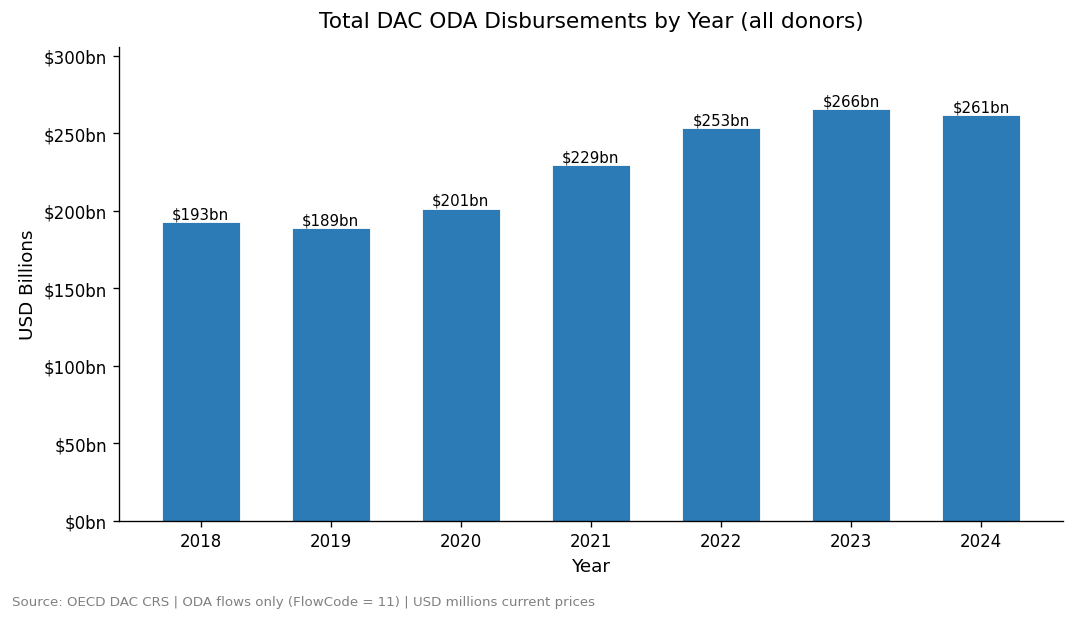

Chart saved to output/charts/oda_by_year.png


In [13]:
# Bar chart — total ODA by year
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    annual_oda['Year'],
    annual_oda['USD_bn'],
    color=BLUE,
    width=0.6,
    edgecolor='white',
    linewidth=0.5,
)

# Add value labels on top of each bar
for bar, val in zip(bars, annual_oda['USD_bn']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'${val:.0f}bn',
        ha='center', va='bottom', fontsize=9,
    )

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('USD Billions', fontsize=11)
ax.set_title('Total DAC ODA Disbursements by Year (all donors)', fontsize=13, pad=12)
ax.set_xticks(annual_oda['Year'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}bn'))
ax.set_ylim(0, annual_oda['USD_bn'].max() * 1.15)

# Source note
fig.text(
    0.01, -0.02,
    'Source: OECD DAC CRS | ODA flows only (FlowCode = 11) | USD millions current prices',
    fontsize=8, color='grey',
)

plt.tight_layout()
plt.savefig(project_root / 'output' / 'charts' / 'oda_by_year.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to output/charts/oda_by_year.png')

## 8. Flag data quality issues

In [14]:
# Check: are all target years present?
target_years   = list(range(2018, 2025))
present_years  = sorted(df['Year'].dropna().unique().astype(int))
missing_years  = [y for y in target_years if y not in present_years]

print('=== DATA QUALITY FLAGS ===')
print()

if missing_years:
    print(f'[FLAG] Missing years: {missing_years}')
else:
    print('[OK] All years 2018–2024 present')

# Check: any year with suspiciously few rows (< 10k might signal incomplete data)
rows_per_year = df.groupby('Year').size().reset_index(name='row_count')
print()
print('Row count by year:')
print(rows_per_year.to_string(index=False))

low_years = rows_per_year[rows_per_year['row_count'] < 10_000]
if not low_years.empty:
    print()
    print('[FLAG] Low row count (< 10,000 rows) — may be incomplete:')
    print(low_years.to_string(index=False))

# Check: any donors that disappear after 2023 (could signal US cuts)
print()
donors_2023 = set(df[df['Year'] == 2023]['DonorName'].dropna().unique())
donors_2024 = set(df[df['Year'] == 2024]['DonorName'].dropna().unique())
disappeared = donors_2023 - donors_2024

if disappeared:
    print(f'[FLAG] Donors in 2023 but NOT in 2024 ({len(disappeared)}):')
    for d in sorted(disappeared):
        print(f'       {d}')
else:
    print('[OK] All 2023 donors also appear in 2024')

print()
print('===========================')

=== DATA QUALITY FLAGS ===

[OK] All years 2018–2024 present

Row count by year:
 Year  row_count
 2018     236292
 2019     240521
 2020     253545
 2021     337510
 2022     307595
 2023     327278
 2024     295303

[FLAG] Donors in 2023 but NOT in 2024 (3):
       IMF (Concessional Trust Funds)
       OPEC Fund for International Development
       UN Women



## 9. Summary for Step 2 sign-off

Review the outputs above before proceeding to Step 3 (OCHA FTS).

Key things to verify:
- [ ] Row count looks plausible (expect hundreds of thousands of rows)
- [ ] All years 2018–2024 present
- [ ] USA appears in donor list with a recognisable name
- [ ] USA is top 1–3 donor by 2023 disbursement
- [ ] Sectors list looks like CRS purpose codes (Health, Education, etc.)
- [ ] No suspicious year-on-year jumps in total ODA (would flag data error)